# DFT Ground-State Energy of the Helium Atom

We compute the ground-state energy of helium from scratch, in **atomic units**
($\hbar = m_e = e = 4\pi\varepsilon_0 = 1$; length in Bohr, energy in Hartree).

The plan, built one milestone at a time (see `pdocs/project_spec.md`):

- **M0** — Scaffolding: radial grid, parameters, one reusable integrator.
- **M1** — Hydrogen radial solver: one electron in a bare nucleus $-Z/r$.
- **M2** — Hartree potential: the repulsion the electron cloud creates.
- **M3** — Self-consistent helium, Hartree only (no exchange-correlation).
- M4 — Add LDA (Slater) exchange ($\approx -2.72$). M5 — Add LDA correlation
  ($\approx -2.83$). M6 — Figures.

**This notebook currently covers M0, M1, M2, and M3.**

**Code layout.** The validated physics lives in the module **`dft.py`** (grid,
integrator, Numerov solver, root finder, Poisson solver, SCF loop). This notebook
imports from it and keeps only the narrative, the demo calls, and the plots — so
the notebook and the test suite (`tests/test_dft.py`) exercise *exactly the same*
code. Run `pytest -v` to check every milestone's validation gate at once.

The headline idea: with two electrons the problem is not analytically solvable
because each electron feels the other. DFT sidesteps this by tracking the
**electron cloud** (the density) instead of the individual electrons, and
solving a self-consistent loop. But first we must be able to solve the simplest
case exactly — a single electron near a nucleus — which is M1.

---
## Milestone 0 — Scaffolding

**Goal:** a notebook that runs top to bottom, with the pieces every later
milestone reuses:

1. A **radial grid**. Because the 1s orbital is spherically symmetric, every
   quantity depends only on the radius $r$. We discretise $r$ on a uniform grid.
2. A **parameters block** (nuclear charge $Z$, step $h$, outer radius $r_{max}$,
   trial energy) so the physics inputs live in one place.
3. One **reusable 1-D integrator**. We need $\int f(r)\,dr$ repeatedly (to
   normalise the wavefunction, to build the Hartree energy, etc.), so we write
   it once.

**Key pitfall (from the spec):** potentials go as $1/r$, which blows up at
$r=0$. So the grid **starts at $r = h$, not $r = 0$**. We never evaluate
anything at the origin.

**Validation gate:** the notebook executes with no error and prints a smoke test.

In [1]:
# Only numpy and matplotlib are allowed (spec section 3). The numerics
# (integration, root finding, Poisson) are all hand-written in dft.py on
# purpose, so that every line is explainable to an examiner.
import numpy as np
import matplotlib.pyplot as plt

# The physics engine. We import the functions by name so the demo cells below
# read naturally (find_eigenvalue(...), hartree_potential(...), etc.).
import dft
from dft import (make_grid, integrate, solve_radial, shoot, normalise,
                 eigenstate, find_eigenvalue, hartree_potential, scf_no_xc,
                 H_STEP, R_MAX)

In [2]:
# ----------------------------------------------------------------------------
# Parameters block: the physical / numerical inputs.
# ----------------------------------------------------------------------------
# Z      : nuclear charge. Z = 1 is hydrogen (our M1 warm-up), Z = 2 is helium.
# H_STEP : grid spacing in Bohr (defined in dft.py). We use 0.001: the steep
#          e^{-Zr} cusp of the Z=2 orbital needs fine resolution near the nucleus
#          to hit E=-2.0 (at h=0.005 the Z=2 eigenvalue is off by ~1.5e-3; at
#          0.001, ~6e-5). The spec recommends the 0.001-0.01 range.
# R_MAX  : outer edge of the grid in Bohr (defined in dft.py). The 1s orbital
#          decays like e^{-Zr}, so by ~25 Bohr it is negligible -- effectively
#          "infinity", far enough that the boundary does not distort the answer.
# The grid starts at r = h (NOT 0): the potentials go as 1/r and would blow up
# at the origin, so we step one point out and never evaluate anything at r = 0.
Z = 2.0          # default to helium's nucleus; the demos below override per test

r = make_grid()  # uniform grid r = h, 2h, ..., r_max (uses dft.H_STEP, dft.R_MAX)
print(f"Grid: N = {len(r)} points, r[0] = {r[0]:.4f} Bohr, "
      f"r[-1] = {r[-1]:.4f} Bohr, h = {H_STEP} Bohr")

Grid: N = 25000 points, r[0] = 0.0010 Bohr, r[-1] = 25.0000 Bohr, h = 0.001 Bohr


In [3]:
# M0 smoke test. `integrate` (composite Simpson's rule, defined in dft.py) is the
# one reusable integrator reused everywhere downstream: normalising u (M1), the
# enclosed charge q_max (M2), and the energy integrals (M3+). We test it on a
# function with a known answer before trusting it: integral of e^{-r} over
# [0, inf) is 1. (Our grid starts at h and stops at R_MAX, so we expect ~1.)
test_val = integrate(np.exp(-r))
print(f"M0 smoke test: integral of e^(-r) over the grid = {test_val:.6f} "
      f"(analytic value over [0, inf) = 1.0)")
print("M0 OK: notebook runs, grid + parameters + integrator are in place.")

M0 smoke test: integral of e^(-r) over the grid = 0.999000 (analytic value over [0, inf) = 1.0)
M0 OK: notebook runs, grid + parameters + integrator are in place.


---
## Milestone 1 — Hydrogen radial solver (the core engine)

**Goal:** find the bound-state energy $E$ and wavefunction of a single electron
in a bare nuclear potential $V(r) = -Z/r$. This is the engine we reuse, with a
richer $V(r)$, for every later milestone.

**The equation.** For an $l=0$ (s) state, writing $u(r) = r\,R(r)$, the radial
Schrödinger equation collapses to a clean 1-D form (PDF Eq. 1):

$$ u''(r) = 2\,[\,V(r) - E\,]\,u(r), \qquad V(r) = -\frac{Z}{r}. $$

This has the shape $u'' = g(r)\,u$ with $g(r) = 2[V(r)-E]$.

**How we solve it — three ideas:**

1. **Numerov integration.** A finite-difference scheme tailored to $u'' = g\,u$
   that is accurate to $O(h^6)$:
   $$\Big(1 - \tfrac{h^2}{12}g_{n+1}\Big)u_{n+1}
     = 2\Big(1 + \tfrac{5h^2}{12}g_n\Big)u_n
     - \Big(1 - \tfrac{h^2}{12}g_{n-1}\Big)u_{n-1}.$$

2. **Integrate inward** (from $r_{max}$ toward $r=0$), *not* outward. Far away
   the physical bound state decays as $e^{-\kappa r}$ with $\kappa=\sqrt{-2E}$.
   Stepping inward, this decaying solution *grows*, while the unphysical
   $e^{+\kappa r}$ solution *shrinks away* — so inward integration automatically
   stays locked onto the physical solution. We seed it at the outer edge with
   $u(r_{max}) = r_{max}\,e^{-\kappa r_{max}}$ and the same form one step in. The
   overall scale is arbitrary (the equation is linear); we fix it later by
   normalising.

3. **Bisection on $E$.** A bound state must also satisfy $u(0)=0$. For a random
   $E$ the inward solution will *not* vanish at the origin — extrapolated to
   $r=0$ it lands at some nonzero value $u(0;E)$. As $E$ sweeps through a true
   eigenvalue, $u(0;E)$ changes sign. We bracket that sign change and bisect to
   pin down $E$. The **lowest** such $E$ is the ground state (no nodes).

**Validation gate:**
- $Z=1 \Rightarrow E = -0.5$ Ha and $u(r) \approx 2\,r\,e^{-r}$ (hydrogen 1s).
- $Z=2 \Rightarrow E = -2.0$ Ha (bare He$^+$, value $-Z^2/2$).

In [4]:
# ----------------------------------------------------------------------------
# VALIDATION GATE 1a: hydrogen, Z = 1. Expect E = -0.5 Ha, u(r) ~ 2 r e^{-r}.
# ----------------------------------------------------------------------------
E_H, u_H = find_eigenvalue(Z=1.0, r=r)

# Analytic hydrogen 1s, already normalised: integral (2 r e^{-r})^2 dr = 1.
u_H_exact = 2.0 * r * np.exp(-r)
max_wf_err = np.max(np.abs(u_H - u_H_exact))

print("VALIDATION 1a  (hydrogen, Z = 1)")
print(f"  Energy E      = {E_H:.6f} Ha     target = -0.500000 Ha")
print(f"  |E - target|  = {abs(E_H - (-0.5)):.2e} Ha")
print(f"  max|u - 2r e^-r| over grid = {max_wf_err:.2e}  (want ~0)")
print(f"  normalisation: integral u^2 dr = {integrate(u_H * u_H):.6f}  (want 1)")
ok_1a = abs(E_H - (-0.5)) < 1e-3 and max_wf_err < 1e-2
print(f"  --> {'PASS' if ok_1a else 'FAIL'}")

VALIDATION 1a  (hydrogen, Z = 1)
  Energy E      = -0.499996 Ha     target = -0.500000 Ha
  |E - target|  = 3.98e-06 Ha
  max|u - 2r e^-r| over grid = 6.77e-06  (want ~0)
  normalisation: integral u^2 dr = 1.000000  (want 1)
  --> PASS


In [5]:
# ----------------------------------------------------------------------------
# VALIDATION GATE 1b: bare He+ nucleus, Z = 2, no electron-electron repulsion
# yet. The exact one-electron result is E = -Z^2/2 = -2.0 Ha.
# ----------------------------------------------------------------------------
E_He, u_He = find_eigenvalue(Z=2.0, r=r)

# Analytic He+ 1s for reference: u = 2 Z^{3/2} r e^{-Z r}, normalised.
u_He_exact = 2.0 * Z**1.5 * r * np.exp(-2.0 * r)  # Z = 2 here
max_wf_err_He = np.max(np.abs(u_He - u_He_exact))

print("VALIDATION 1b  (bare He+ nucleus, Z = 2, no Hartree)")
print(f"  Energy E      = {E_He:.6f} Ha     target = -2.000000 Ha")
print(f"  |E - target|  = {abs(E_He - (-2.0)):.2e} Ha")
print(f"  max|u - 2 Z^1.5 r e^-Zr| over grid = {max_wf_err_He:.2e}  (want ~0)")
print(f"  normalisation: integral u^2 dr = {integrate(u_He * u_He):.6f}  (want 1)")
ok_1b = abs(E_He - (-2.0)) < 1e-3
print(f"  --> {'PASS' if ok_1b else 'FAIL'}")

print()
print("=" * 60)
print(f"MILESTONE 1 OVERALL: {'PASS' if (ok_1a and ok_1b) else 'FAIL'}")
print("=" * 60)

VALIDATION 1b  (bare He+ nucleus, Z = 2, no Hartree)
  Energy E      = -1.999937 Ha     target = -2.000000 Ha
  |E - target|  = 6.35e-05 Ha
  max|u - 2 Z^1.5 r e^-Zr| over grid = 3.81e-05  (want ~0)
  normalisation: integral u^2 dr = 1.000000  (want 1)
  --> PASS

MILESTONE 1 OVERALL: PASS


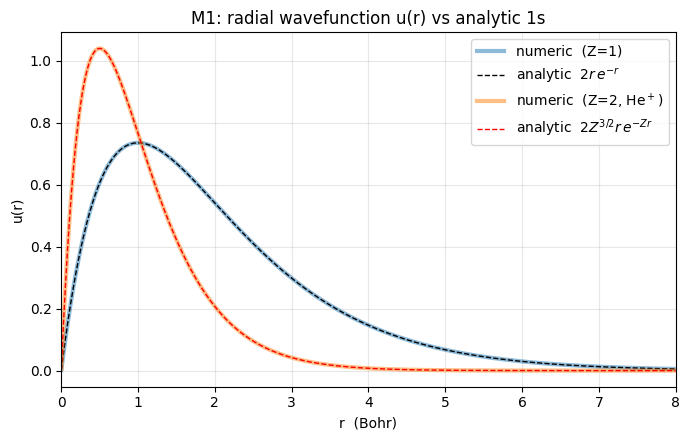

In [6]:
# Visual check: the numeric u(r) should sit right on top of the analytic curve.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(r, u_H, lw=3, alpha=0.5, label="numeric  (Z=1)")
ax.plot(r, u_H_exact, "k--", lw=1, label=r"analytic  $2r\,e^{-r}$")
ax.plot(r, u_He, lw=3, alpha=0.5, label="numeric  (Z=2, He$^+$)")
ax.plot(r, u_He_exact, "r--", lw=1, label=r"analytic  $2Z^{3/2}r\,e^{-Zr}$")
ax.set_xlim(0, 8)
ax.set_xlabel("r  (Bohr)")
ax.set_ylabel("u(r)")
ax.set_title("M1: radial wavefunction u(r) vs analytic 1s")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Milestone 2 — Hartree potential via Poisson

**Goal:** given the electron cloud's shape $u(r)$, compute the electrostatic
**repulsion** that cloud creates — the *Hartree potential* $V_H(r)$. This is the
"uphill" term the next electron feels, and the first genuinely many-electron
piece of physics.

**The trick — turn an integral into an ODE.** $V_H$ is in principle a 3-D
integral over all the charge (PDF Eq. 2). But for a spherical cloud it satisfies
the radial Poisson equation, and substituting $U(r) = r\,V_H(r)$ collapses it to
a clean 1-D second-order ODE (PDF Eqs. 4–6; the $4\pi$ cancels against the
normalisation):

$$ U''(r) = -\frac{u(r)^2}{r}. $$

The right-hand side is the (spherically averaged) charge source.

**Boundary conditions (PDF Eqs. 7–10):**
- $U(0) = 0$ — the potential$\times r$ vanishes at the origin.
- $U(r_{max}) = q_{max} = \int_0^{r_{max}} u^2\,dr$ — the enclosed charge, which
  $\to 1$ for a normalised orbital (all the charge sits inside $r_{max}$).

**Method (three steps):**
1. Integrate $U'' = s(r)$, $s=-u^2/r$, **outward** with the Verlet/second-
   difference scheme $U_{n+1} = 2U_n - U_{n-1} + h^2 s_n$, starting from the
   virtual origin $U(0)=0$ with an arbitrary slope.
2. Any two solutions with $U(0)=0$ differ only by a multiple of the homogeneous
   solution $\alpha r$ (the constant homogeneous solution is killed by $U(0)=0$).
   So add $\alpha r$ with $\alpha = (q_{max} - U(r_{max}))/r_{max}$ to fix the
   outer boundary exactly — without disturbing $U(0)=0$.
3. $V_H(r) = U(r)/r$.

**Validation gate:** feed in the hydrogen 1s density and reproduce the exact
closed form $U(r) = -(r+1)e^{-2r} + 1$ (equivalently
$V_H(r) = 1/r - (1+1/r)e^{-2r}$). This is an analytic target that pins the solver
down completely.

In [7]:
# ----------------------------------------------------------------------------
# VALIDATION GATE 2: feed the hydrogen 1s density into the Poisson solver and
# compare against the exact closed form U(r) = -(r+1) e^{-2r} + 1.
# ----------------------------------------------------------------------------
# Reuse the normalised hydrogen ground state from M1 (Z = 1). The density MUST
# be normalised before this step (q_max relies on it).
E_H, u_H = find_eigenvalue(Z=1.0, r=r)
V_H, U, q_max = hartree_potential(u_H, r)

# Exact analytic targets for the hydrogen 1s density.
U_exact = -(r + 1.0) * np.exp(-2.0 * r) + 1.0
VH_exact = 1.0 / r - (1.0 + 1.0 / r) * np.exp(-2.0 * r)

max_U_err = np.max(np.abs(U - U_exact))
max_VH_err = np.max(np.abs(V_H - VH_exact))

print("VALIDATION 2  (Hartree potential, hydrogen 1s density)")
print(f"  enclosed charge q_max         = {q_max:.6f}   target = 1.0")
print(f"  max|U(r)  - (-(r+1)e^-2r + 1)| = {max_U_err:.2e}   (want ~0)")
print(f"  max|V_H(r) - (1/r-(1+1/r)e^-2r)| = {max_VH_err:.2e}   (want ~0)")
ok_2 = abs(q_max - 1.0) < 1e-3 and max_U_err < 1e-3 and max_VH_err < 1e-3
print(f"  --> {'PASS' if ok_2 else 'FAIL'}")

VALIDATION 2  (Hartree potential, hydrogen 1s density)
  enclosed charge q_max         = 1.000000   target = 1.0
  max|U(r)  - (-(r+1)e^-2r + 1)| = 3.55e-06   (want ~0)
  max|V_H(r) - (1/r-(1+1/r)e^-2r)| = 1.16e-05   (want ~0)
  --> PASS


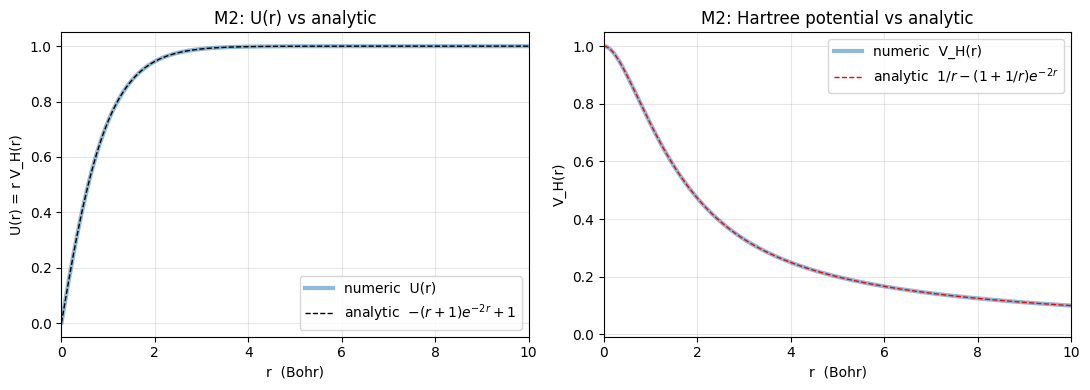

In [8]:
# Visual check: numeric U(r) and V_H(r) should lie on top of the analytic forms.
fig, (axU, axV) = plt.subplots(1, 2, figsize=(11, 4))

axU.plot(r, U, lw=3, alpha=0.5, label="numeric  U(r)")
axU.plot(r, U_exact, "k--", lw=1, label=r"analytic  $-(r+1)e^{-2r}+1$")
axU.set_xlim(0, 10)
axU.set_xlabel("r  (Bohr)")
axU.set_ylabel("U(r) = r V_H(r)")
axU.set_title("M2: U(r) vs analytic")
axU.legend()
axU.grid(alpha=0.3)

axV.plot(r, V_H, lw=3, alpha=0.5, label="numeric  V_H(r)")
axV.plot(r, VH_exact, "r--", lw=1, label=r"analytic  $1/r-(1+1/r)e^{-2r}$")
axV.set_xlim(0, 10)
axV.set_xlabel("r  (Bohr)")
axV.set_ylabel("V_H(r)")
axV.set_title("M2: Hartree potential vs analytic")
axV.legend()
axV.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Milestone 3 — Self-consistent helium, Hartree only (no exchange-correlation)

**Goal:** the first real two-electron helium energy. Both electrons sit in the
same 1s orbital; each feels the nucleus **and** the cloud of the other electron.

**The circular problem.** The potential an electron sees depends on where the
other electron is (its cloud → $V_H$), but where the electrons sit depends on the
potential. We resolve this by **self-consistency (SCF)**: guess a potential,
solve for the orbital, rebuild $V_H$ from the new orbital, and repeat until the
eigenvalue stops moving. We damp oscillation with **potential mixing**
$V_H \leftarrow (1-w)V_H^{\text{old}} + w\,V_H^{\text{new}}$, $w\approx0.3$.

**The factor-of-2 bookkeeping (the classic trap).** With two electrons the naive
Hartree term would double-count and would also let each electron repel *itself*.
In this no-XC milestone the factor 2 from spin (two electrons in one orbital)
exactly cancels the $\tfrac12$ that removes the self-interaction, so the
effective $V_H$ is just the potential of a **single normalised orbital density**
— precisely what `hartree_potential` already returns. So we use it directly:
$$ V(r) = -\frac{2}{r} + V_H(r). $$

**Total energy (PDF Eq. 13):**
$$ E = 2\varepsilon - \int V_H(r)\,u(r)^2\,dr. $$
The $2\varepsilon$ sums both electrons' single-particle energies; each already
contains the electron-electron interaction once, so summing double-counts it, and
subtracting $\int V_H u^2$ removes the extra count.

**Validation gate: $E = -2.86$ Ha.**

> **Why −2.86 and not −2.72.** This is the *restricted Hartree-Fock* value, and
> it is the **correct** M3 answer — not a bug. For a two-electron closed-shell
> singlet (both electrons in one spatial 1s orbital) the self-interaction-removed
> Hartree potential coincides *exactly* with the RHF potential, because HF
> exchange does nothing more than cancel the self-interaction: with one occupied
> orbital $(2J-K)\phi = (2J-J)\phi = J\phi$. So **SIC-Hartree $\equiv$ RHF** for
> helium. The often-quoted **−2.72** is a *later* milestone (M4: full Hartree
> **plus Slater exchange**, no correlation), confirmed by the assignment PDF
> (p. 5), which quotes −2.72 in the section where Slater exchange is already on.

In [9]:
# ----------------------------------------------------------------------------
# VALIDATION GATE 3: run the SCF loop for helium (Z = 2), Hartree only.
# scf_no_xc prints E at each iteration so convergence is visible (spec rule).
# ----------------------------------------------------------------------------
scf = scf_no_xc(Z=2.0, r=r, w=0.3, tol=1e-7, verbose=True)

print()
print("VALIDATION 3  (self-consistent helium, Hartree only, no XC)")
print(f"  converged in {scf['iterations']} iterations")
print(f"  eigenvalue eps = {scf['eps']:.6f} Ha")
print(f"  total energy E = {scf['E']:.6f} Ha     target = -2.86 Ha (= RHF)")
print(f"  |E - target|   = {abs(scf['E'] - (-2.86)):.2e} Ha")
ok_3 = abs(scf['E'] - (-2.86)) < 1e-2
print(f"  --> {'PASS' if ok_3 else 'FAIL'}")
print("  (Reaching the RHF value -2.86 is correct for a 2-electron singlet;")
print("   the -2.72 figure arrives in M4 once Slater exchange is added.)")

iter      eps (Ha)    E_total (Ha)       d eps
   1     -0.820676       -2.604019         nan
   2     -0.858483       -2.704817    3.78e-02
   3     -0.881698       -2.766210    2.32e-02
   4     -0.895894       -2.803598    1.42e-02
   5     -0.904552       -2.826358    8.66e-03
   6     -0.909822       -2.840206    5.27e-03
   7     -0.913024       -2.848625    3.20e-03
   8     -0.914966       -2.853740    1.94e-03
   9     -0.916143       -2.856844    1.18e-03
  10     -0.916855       -2.858726    7.12e-04
  11     -0.917284       -2.859865    4.29e-04
  12     -0.917543       -2.860554    2.59e-04
  13     -0.917698       -2.860969    1.55e-04
  14     -0.917791       -2.861219    9.31e-05
  15     -0.917847       -2.861370    5.56e-05
  16     -0.917880       -2.861460    3.31e-05
  17     -0.917900       -2.861513    1.96e-05
  18     -0.917911       -2.861545    1.15e-05
  19     -0.917918       -2.861564    6.74e-06
  20     -0.917922       -2.861575    3.91e-06
  21     -0.9

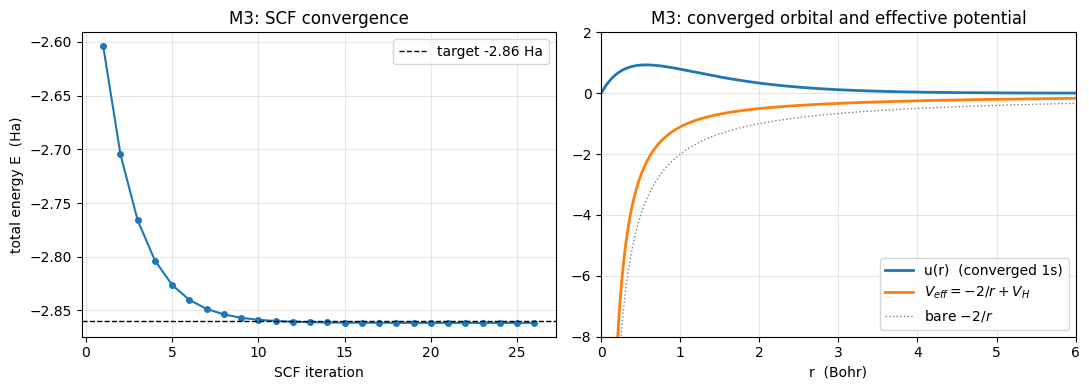

In [10]:
# Two views of the converged SCF solution.
fig, (axc, axp) = plt.subplots(1, 2, figsize=(11, 4))

# (a) Convergence: total energy vs SCF iteration, approaching -2.86.
E_hist = [E for (eps, E) in scf["history"]]
axc.plot(range(1, len(E_hist) + 1), E_hist, "o-", ms=4)
axc.axhline(-2.86, color="k", ls="--", lw=1, label="target -2.86 Ha")
axc.set_xlabel("SCF iteration")
axc.set_ylabel("total energy E  (Ha)")
axc.set_title("M3: SCF convergence")
axc.legend()
axc.grid(alpha=0.3)

# (b) The converged orbital u(r) and the effective potential it lives in.
u_he = scf["u"]
V_eff = -2.0 / r + scf["V_H"]
axp.plot(r, u_he, lw=2, label="u(r)  (converged 1s)")
axp.plot(r, V_eff, lw=2, label=r"$V_{eff}=-2/r+V_H$")
axp.plot(r, -2.0 / r, lw=1, ls=":", color="grey", label=r"bare $-2/r$")
axp.set_xlim(0, 6)
axp.set_ylim(-8, 2)
axp.set_xlabel("r  (Bohr)")
axp.set_title("M3: converged orbital and effective potential")
axp.legend()
axp.grid(alpha=0.3)

plt.tight_layout()
plt.show()